# Multivariate Linear Regression and Feature Scaling

> 📖 Book: [ch04](../../.claude/skills/ml-knowledge/chapters/ch04-linear-regression-gradient-descent.md), [ch05 – Features, normalization](../../.claude/skills/ml-knowledge/chapters/ch05-features-polynomial-regression-overfitting.md) · Prev: [05](05_gd_quadratic_interp_cg_bfgs.ipynb) · Next: [07 Polynomial regression](07_polynomial_regression.ipynb)

Also known as *multivariate linear regression*. With one feature we fit a line; with $n$ features we fit a **hyperplane**:

$$
h_\theta(\mathbf{x}) = \theta_0 + \theta_1x_1 + \theta_2x_2 + \dots + \theta_nx_n = \mathbf{x}^T\theta ,
$$

with the convention $x_0 = 1$ so that $\mathbf{x}$ and $\theta$ both have $n + 1$ entries.

**Notation**: $x_j^{(i)}$ is feature $j$ of example $i$; $\mathbf{x}^{(i)}$ all features of example $i$; $x_j$ feature $j$ over all examples (column $j$ of $X$); $m$ examples, $n$ features.

Intuition for houses: $\theta_0$ is a base price, $\theta_1$ the price per $m^2$, $\theta_2$ the price per bedroom…

Gradient descent keeps the same form, for every $j$ simultaneously:

$$
\theta_j := \theta_j - \alpha\frac1m\sum_{i=1}^m \left(h_\theta(\mathbf{x}^{(i)}) - y^{(i)}\right)x_j^{(i)}, \qquad j = 0, 1, \dots, n .
$$

## Example: size and bedrooms

| Size ($m^2$) | Bedrooms | Price (USD) |
|:---:|:---:|:---:|
| 820 | 2 | 70000 |
| 910 | 2 | 83000 |
| 1100 | 2 | 75000 |
| 1100 | 3 | 93000 |
| 1400 | 3 | 90000 |
| 1400 | 2 | 80000 |
| 1500 | 4 | 85000 |
| 1600 | 4 | 114000 |
| 1804 | 3 | 150000 |
| 2010 | 3 | 160050 |
| 2040 | 4 | 170000 |
| 2500 | 4 | 175000 |
| 3200 | 5 | 180000 |
| 3400 | 4 | 190000 |

$$
X = \begin{pmatrix} 1 & 820 & 2 \\ 1 & 910 & 2 \\ \vdots & \vdots & \vdots \\ 1 & 3400 & 4 \end{pmatrix}, \quad
\theta = \begin{pmatrix} \theta_0 \\ \theta_1 \\ \theta_2 \end{pmatrix}, \quad
y = \begin{pmatrix} 70000 \\ 83000 \\ \vdots \\ 190000 \end{pmatrix}.
$$

normal equations theta: [27777.29    49.68  2108.69]


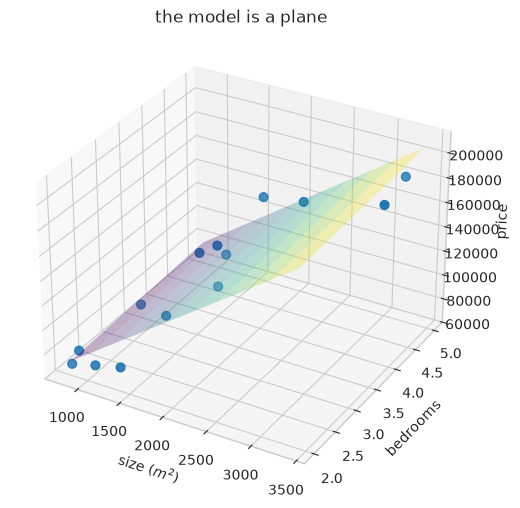

In [1]:
import matplotlib.pyplot as plt
import numpy as np

from ml.features.scaling import mean_normalize, min_max, standardize, unit_norm
from ml.linalg import condition_number
from ml.linear_models import add_bias, mse_cost, mse_gradient, normal_equations
from ml.optimization import gradient_descent

plt.style.use("seaborn-v0_8-whitegrid")

size = np.array([820, 910, 1100, 1100, 1400, 1400, 1500, 1600, 1804, 2010, 2040, 2500, 3200, 3400], dtype=float)
rooms = np.array([2, 2, 2, 3, 3, 2, 4, 4, 3, 3, 4, 4, 5, 4], dtype=float)
price = np.array([70000, 83000, 75000, 93000, 90000, 80000, 85000, 114000, 150000, 160050, 170000, 175000, 180000, 190000], dtype=float)
F = np.column_stack([size, rooms])
X = add_bias(F)
theta_ne = normal_equations(X, price)
print("normal equations theta:", theta_ne.round(2))

ax = plt.figure(figsize=(7, 6)).add_subplot(projection="3d")
ax.scatter(size, rooms, price, c="C0", s=40)
S, R = np.meshgrid(np.linspace(800, 3400, 10), np.linspace(2, 5, 10))
ax.plot_surface(S, R, theta_ne[0] + theta_ne[1] * S + theta_ne[2] * R, alpha=0.3, cmap="viridis")
ax.set(xlabel="size ($m^2$)", ylabel="bedrooms", zlabel="price", title="the model is a plane")
plt.show()

# Feature normalization

Bedrooms range from 2 to 5, while sizes are three orders of magnitude larger. This discrepancy between the columns of $X$ slows gradient descent down: the contours of $J$ become extremely elongated ellipses. Bringing the columns to similar ranges makes the contours rounder, and GD converges faster. Equivalently, it reduces the spread of the singular values of $X$, i.e. the **condition number** $\kappa$, making the system more stable.

Feature normalization:

1. Speeds up convergence by reducing the zig-zag of gradient descent.
2. Improves accuracy and stability by reducing $\kappa$.
3. Gives meaningful distances not dominated by large-valued features (important for $k$-NN, $k$-means, SVMs…).

Doesn't normalizing change the solution? We now solve $X_n\theta_n = y$ instead of $X\theta = y$. The prices $y$ don't change, but $\theta_n$ lives in the normalized units. **To predict, apply exactly the same normalization (same $\mu_j, \sigma_j$ from training) to the new data** before using $\theta_n$. That's why every scaler in `ml.features.scaling` returns the fitted `transform`.

## Normalization techniques

Applied column by column, **never to the bias column of ones**.

**Standardization (z-score)**: zero mean, unit standard deviation,

$$
x_j := \frac{x_j - \mu_j}{\sigma_j}, \qquad \mu_j = \frac1m\sum_{i=1}^m x_j^{(i)}, \quad \sigma_j = \sqrt{\frac1m\sum_{i=1}^m\left(x_j^{(i)} - \mu_j\right)^2}.
$$

**Mean normalization**: subtract the mean, divide by the range,

$$
x_j := \frac{x_j - \mu_j}{\max_i x_j^{(i)} - \min_i x_j^{(i)}} .
$$

**Min–max scaling**: values in $[0, 1]$ (0 at the minimum, 1 at the maximum),

$$
x_j := \frac{x_j - \min_i x_j^{(i)}}{\max_i x_j^{(i)} - \min_i x_j^{(i)}} .
$$

**Unit-norm scaling**: each column gets norm 1,

$$
x_j := \frac{x_j}{\|x_j\|} .
$$

Rule of thumb: aim for roughly $-1 \le x_j \le 1$.

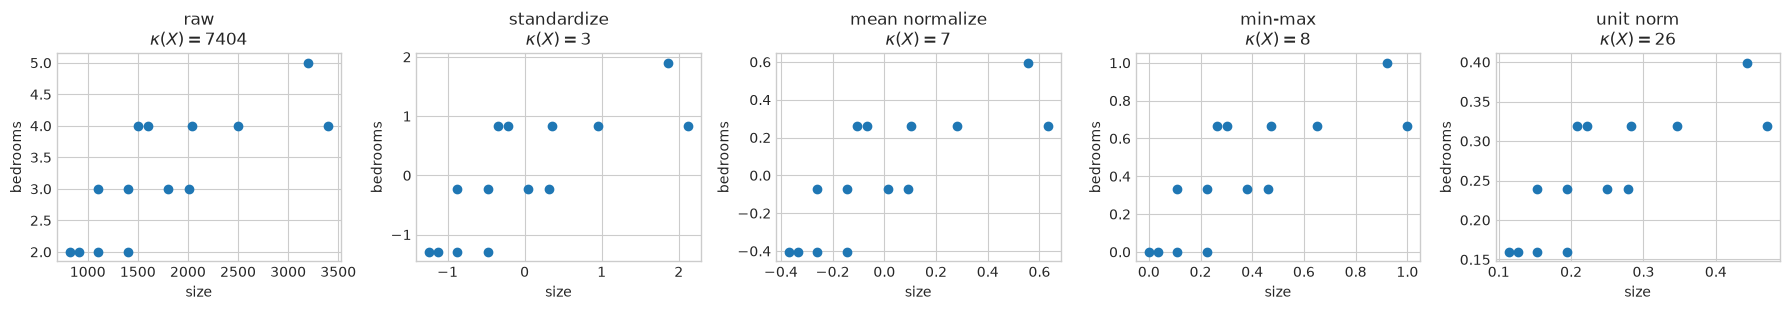

In [2]:
scalers = {"raw": None, "standardize": standardize, "mean normalize": mean_normalize, "min-max": min_max, "unit norm": unit_norm}
fig, axes = plt.subplots(1, len(scalers), figsize=(18, 3.2))
for ax, (name, scaler) in zip(axes, scalers.items(), strict=True):
    Z = F if scaler is None else scaler(F)[0]
    ax.scatter(Z[:, 0], Z[:, 1])
    ax.set(title=f"{name}\n$\\kappa(X) = {condition_number(add_bias(Z)):.0f}$", xlabel="size", ylabel="bedrooms")
plt.tight_layout()
plt.show()

## Effect on gradient descent

We run GD on the MSE cost with raw and standardized features, using the largest $\alpha$ that doesn't diverge in each case ($\alpha < 2/\lambda_{max}$ of the Hessian $\frac1mX^TX$).

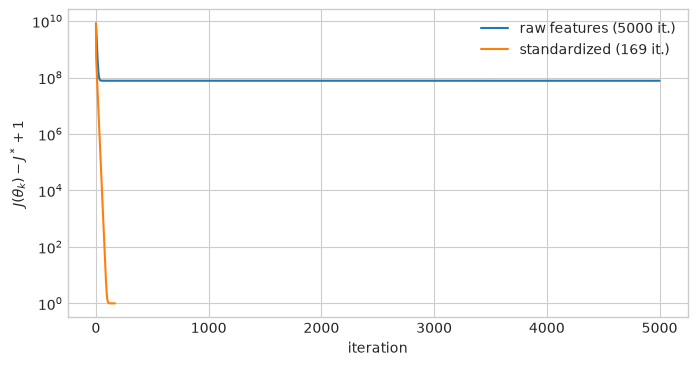

prediction, normal equations (raw)   : [83784.]
prediction, GD on standardized data  : [83784.]
prediction, GD on raw data (5000 it.): [66454.]


In [3]:
def run(Xd, max_iter):
    lam_max = np.linalg.eigvalsh(Xd.T @ Xd / len(price)).max()
    return gradient_descent(
        lambda t: mse_cost(t, Xd, price), lambda t: mse_gradient(t, Xd, price),
        np.zeros(Xd.shape[1]), alpha=1.9 / lam_max, tol=1e-3, max_iter=max_iter,
    )


Z, transform = standardize(F)
Xz = add_bias(Z)
theta_raw, h_raw = run(X, 5000)
theta_z, h_z = run(Xz, 5000)

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(h_raw[:, -1] - mse_cost(theta_ne, X, price) + 1, label=f"raw features ({len(h_raw) - 1} it.)")
ax.semilogy(h_z[:, -1] - mse_cost(theta_ne, X, price) + 1, label=f"standardized ({len(h_z) - 1} it.)")
ax.set(xlabel="iteration", ylabel=r"$J(\theta_k) - J^* + 1$")
ax.legend()
plt.show()

house = np.array([[1000.0, 3.0]])
print("prediction, normal equations (raw)   :", (add_bias(house) @ theta_ne).round(0))
print("prediction, GD on standardized data  :", (add_bias(transform(house)) @ theta_z).round(0))
print("prediction, GD on raw data (5000 it.):", (add_bias(house) @ theta_raw).round(0))

With standardized features GD reaches the normal-equation solution in a handful of iterations and, using the *same* `transform` on the new house, gives the same prediction. On raw features it is still far away after thousands of iterations.